01_eda.ipynb — Khám phá dữ liệu (EDA)


# Cell 1 — Import thư viện


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Cell 2 — Load dataset

In [2]:
import pandas as pd

yield_df = pd.read_csv("D:/HocTap/DATA_MINING/DATA_MINING_PROJECT/data/raw/yield_df.csv")

yield_df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


# Cell 3 — Xem thông tin dataset


In [3]:
yield_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [4]:
yield_df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


# Cell 4 — Kiểm tra missing value


In [5]:
yield_df.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

# Cell 5 — Kiểm tra số lượng quốc gia và cây trồng


In [6]:
yield_df["Area"].nunique()

101

Phân bố năng suất


In [8]:
yield_df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='str')

In [9]:
yield_df = yield_df.rename(columns={
    "hg/ha_yield": "yield"
})

In [10]:
yield_df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='str')

Biểu đồ phân bố Yield


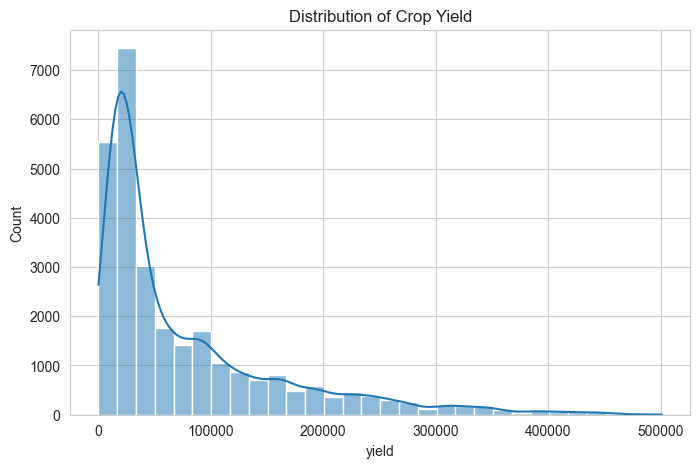

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(yield_df["yield"], bins=30, kde=True)

plt.title("Distribution of Crop Yield")

plt.show()


Yield theo năm


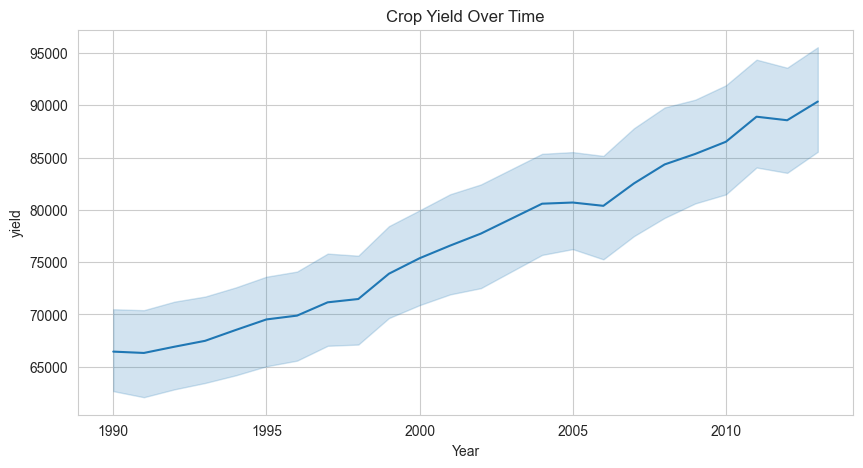

In [12]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x="Year",
    y="yield",
    data=yield_df
)

plt.title("Crop Yield Over Time")

plt.show()

Temperature vs Yield

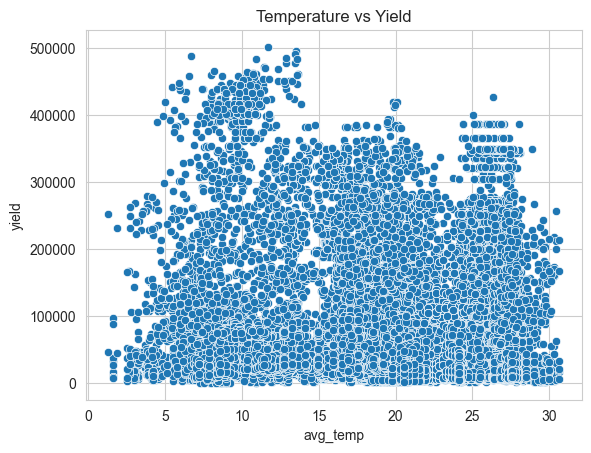

In [13]:
sns.scatterplot(
    x="avg_temp",
    y="yield",
    data=yield_df
)

plt.title("Temperature vs Yield")

plt.show()

Insight

Yield phân bố không đồng đều

Có nhiều vùng năng suất thấp và một số vùng năng suất cao

Điều này cho thấy điều kiện môi trường ảnh hưởng mạnh đến năng suất

# Cell 6: Yield theo loại cây


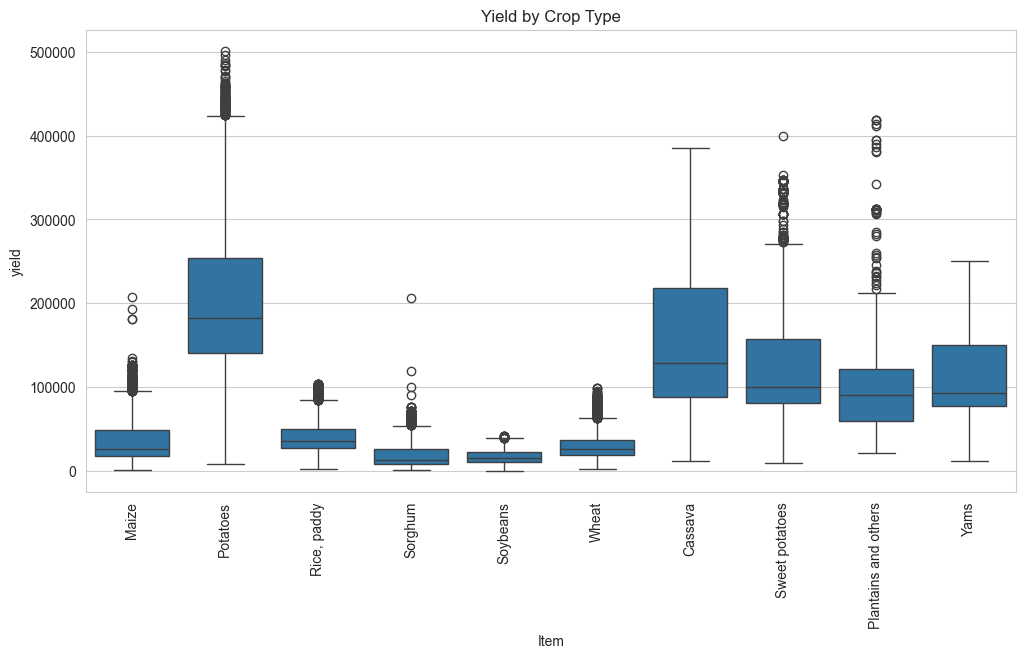

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Item",
    y="yield",
    data=yield_df
)

plt.xticks(rotation=90)

plt.title("Yield by Crop Type")

plt.show()

Insight

Một số cây trồng có năng suất cao hơn

Giống cây là yếu tố quan trọng

# Cell 7 :Rainfall vs Yield

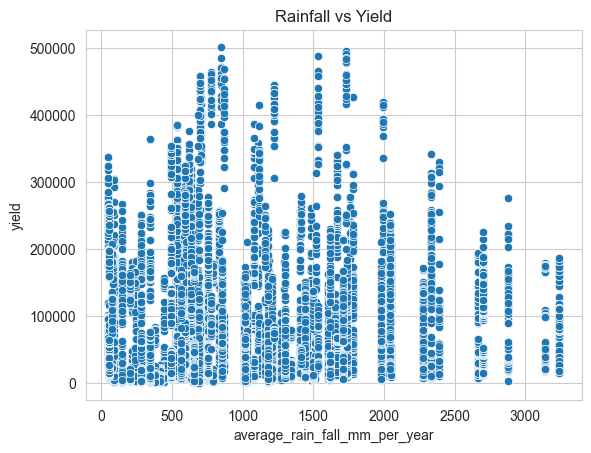

In [15]:
sns.scatterplot(
    x="average_rain_fall_mm_per_year",
    y="yield",
    data=yield_df
)

plt.title("Rainfall vs Yield")

plt.show()

Insight

Lượng mưa vừa phải giúp tăng năng suất

Mưa quá nhiều hoặc quá ít đều ảnh hưởng xấu


# Cell 8: Temperature vs Yield

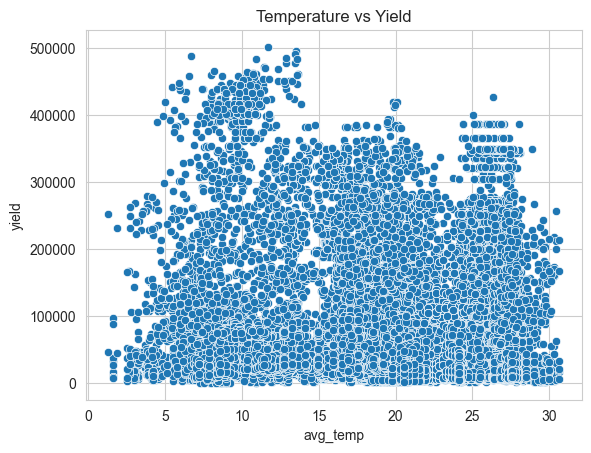

In [16]:
sns.scatterplot(
    x="avg_temp",
    y="yield",
    data=yield_df
)

plt.title("Temperature vs Yield")

plt.show()

Nhiệt độ có ảnh hưởng lớn

Có vùng nhiệt độ tối ưu cho cây

# Cell 9: Correlation matrix


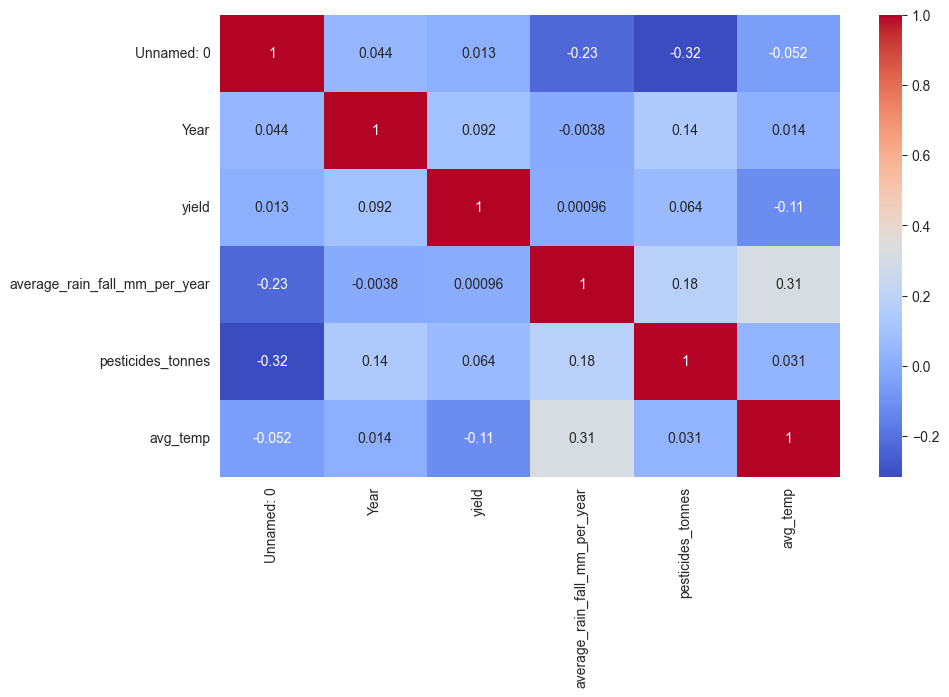

In [17]:
corr = yield_df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()


Temperature và Rainfall có tương quan với Yield

Pesticides ảnh hưởng nhỏ hơn
